
=== PrimeVul | Within-Project: linux | GAN ===
    Device: mps

[1/6] Loading embeddings...
      Train (linux): (43212, 768)  vuln=1002  benign=42210
      Test  (linux): (4140, 768)  vuln=70  benign=4070

[2/6] Normalising embeddings...

[3/6] Applying GAN oversampling...
      Before GAN — benign: 42210 | vuln: 1002 | ratio: 42.13


GAN Training:   0%|          | 0/300 [00:00<?, ?it/s]

      GAN Epoch 50/300 - D_loss: 0.8443 - G_loss: 1.4269
      GAN Epoch 100/300 - D_loss: 0.7559 - G_loss: 1.7675
      GAN Epoch 150/300 - D_loss: 0.9356 - G_loss: 1.9306
      GAN Epoch 200/300 - D_loss: 0.7605 - G_loss: 2.1119
      GAN Epoch 250/300 - D_loss: 0.8747 - G_loss: 1.8742
      GAN Epoch 300/300 - D_loss: 0.9329 - G_loss: 1.8953
      After  GAN — benign: 42210 | vuln: 42210 | ratio: 1.00

[4/6] Computing class weights...
      Class weights (post-GAN): {0: 1.0, 1: 1.0}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


...

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.3787
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.0716
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.0604
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.0573
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.0561
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.0541
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.0531
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.0515
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.0506
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.0501
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.0495
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.0490
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.0486
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.0483
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.0479
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.0476
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.3423
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.0696
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.0637
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.0591
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.0566
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.0551
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.0530
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.0520
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.0505
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.0500
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.0492
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.0487
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.0485
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.0479
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.0474
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.0473
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.3742
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.0753
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.0648
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.0610
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.0585
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.0562
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.0545
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.0536
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.0524
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.0515
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.0509
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.0503
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.0498
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.0494
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.0489
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.0486
 

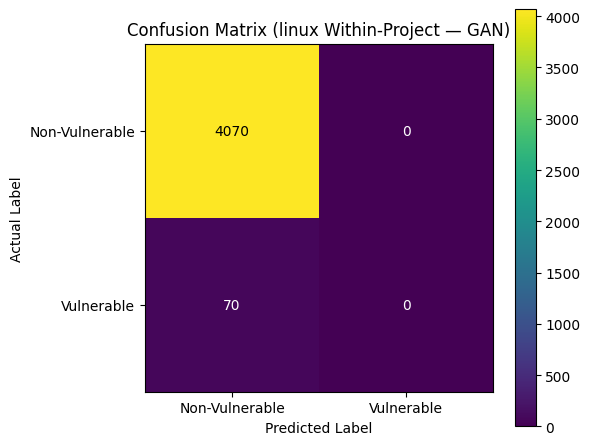

In [1]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on linux (train split) -> Test on linux (test split)
GAN Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED        = 42
PROJECT     = "linux"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/gan"

LATENT_DIM  = 64
GAN_EPOCHS  = 300
GAN_LR      = 1e-4
BATCH_SIZE  = 64

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Main Classifier
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# GAN Models
# =========================================================
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# =========================================================
# GAN Oversampling
# =========================================================
def train_gan_and_generate(minority_samples, n_generate):
    """
    Train a simple GAN on minority-class embeddings only
    and generate synthetic vulnerable samples.
    """
    input_dim = minority_samples.shape[1]

    generator     = Generator(LATENT_DIM, input_dim).to(DEVICE)
    discriminator = Discriminator(input_dim).to(DEVICE)

    g_optimizer = torch.optim.Adam(generator.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
    criterion   = nn.BCELoss()

    minority_tensor = torch.tensor(minority_samples, dtype=torch.float32)
    loader = DataLoader(TensorDataset(minority_tensor), batch_size=min(BATCH_SIZE, len(minority_samples)), shuffle=True)

    for epoch in tqdm(range(GAN_EPOCHS), desc="GAN Training", leave=False):
        for (real_batch,) in loader:
            real_batch = real_batch.to(DEVICE)
            batch_size = real_batch.size(0)

            real_labels = torch.ones(batch_size, 1).to(DEVICE)
            fake_labels = torch.zeros(batch_size, 1).to(DEVICE)

            # Train discriminator
            d_optimizer.zero_grad()
            real_preds = discriminator(real_batch)
            d_loss_real = criterion(real_preds, real_labels)

            z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
            fake_batch = generator(z)
            fake_preds = discriminator(fake_batch.detach())
            d_loss_fake = criterion(fake_preds, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            d_optimizer.step()

            # Train generator
            g_optimizer.zero_grad()
            z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
            fake_batch = generator(z)
            fake_preds = discriminator(fake_batch)
            g_loss = criterion(fake_preds, real_labels)
            g_loss.backward()
            g_optimizer.step()

        if (epoch + 1) % 50 == 0:
            print(f"      GAN Epoch {epoch+1}/{GAN_EPOCHS} - D_loss: {d_loss.item():.4f} - G_loss: {g_loss.item():.4f}")

    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_generate, LATENT_DIM).to(DEVICE)
        synthetic = generator(z).cpu().numpy().astype(np.float32)

    return synthetic


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr, dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr, dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — GAN)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | GAN ===")
    print(f"    Device: {DEVICE}")

    print("\n[1/6] Loading embeddings...")
    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")

    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    print("\n[3/6] Applying GAN oversampling...")
    minority_samples = train_emb[train_lbl == 1]
    majority_samples = train_emb[train_lbl == 0]

    n_neg_before = len(majority_samples)
    n_pos_before = len(minority_samples)
    print(f"      Before GAN — benign: {n_neg_before} | vuln: {n_pos_before} | ratio: {n_neg_before / n_pos_before:.2f}")

    n_to_generate = n_neg_before - n_pos_before
    if n_to_generate > 0 and n_pos_before > 1:
        synthetic_minority = train_gan_and_generate(minority_samples, n_to_generate)
        train_emb_res = np.vstack([train_emb, synthetic_minority]).astype(np.float32)
        train_lbl_res = np.concatenate([train_lbl, np.ones(n_to_generate, dtype=np.int32)])
    else:
        print("      GAN oversampling skipped: insufficient minority samples or already balanced.")
        train_emb_res = train_emb.copy()
        train_lbl_res = train_lbl.copy()

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  GAN — benign: {n_neg_after} | vuln: {n_pos_after} | ratio: {n_neg_after / max(n_pos_after,1):.2f}")

    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w) for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-GAN): {class_weights}")

    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights = np.where(train_lbl_res == 1, y_train_pred, 1 - y_train_pred)
        model_xgb      = train_base_model_xgb(
                             train_emb_res, train_lbl_res,
                             class_weights,
                             sample_weights
                         )
        model_xgb_pred = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl, y_pred_final)
    recall    = recall_score(test_lbl, y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl, ensemble_avg)
    f1        = f1_score(test_lbl, y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"          : "gan_within_project",
        "setting"             : "within_project",
        "project"             : PROJECT,
        "latent_dim"          : LATENT_DIM,
        "gan_epochs"          : GAN_EPOCHS,
        "gan_lr"              : GAN_LR,
        "n_train_before_gan"  : int(len(train_lbl)),
        "n_train_after_gan"   : int(len(train_lbl_res)),
        "n_vuln_before_gan"   : n_pos_before,
        "n_benign_before_gan" : n_neg_before,
        "n_vuln_after_gan"    : n_pos_after,
        "n_benign_after_gan"  : n_neg_after,
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_test"         : int(test_lbl.sum()),
        "class_weights"       : class_weights,
        "accuracy"            : round(float(accuracy), 4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall), 4),
        "f1"                  : round(float(f1), 4),
        "auc"                 : round(float(auc), 4),
        "g_mean"              : round(float(g_mean), 4),
        "pf"                  : round(float(pf), 4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"gan_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_gan_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: tensorflow | GAN ===
    Device: mps

[1/6] Loading embeddings...
      Train (tensorflow): (1089, 768)  vuln=76  benign=1013
      Test  (tensorflow): (1313, 768)  vuln=91  benign=1222

[2/6] Normalising embeddings...

[3/6] Applying GAN oversampling...
      Before GAN — benign: 1013 | vuln: 76 | ratio: 13.33


GAN Training:   0%|          | 0/300 [00:00<?, ?it/s]

      GAN Epoch 50/300 - D_loss: 1.2725 - G_loss: 0.5705
      GAN Epoch 100/300 - D_loss: 0.9961 - G_loss: 0.8730
      GAN Epoch 150/300 - D_loss: 0.7987 - G_loss: 1.0521
      GAN Epoch 200/300 - D_loss: 0.5358 - G_loss: 1.2181
      GAN Epoch 250/300 - D_loss: 0.8020 - G_loss: 1.2656
      GAN Epoch 300/300 - D_loss: 0.7962 - G_loss: 1.1967
      After  GAN — benign: 1013 | vuln: 1013 | ratio: 1.00

[4/6] Computing class weights...
      Class weights (post-GAN): {0: 1.0, 1: 1.0}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


...

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6931
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6911
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6887
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6858
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6824
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6785
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6742
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.6692
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.6632
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.6560
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.6474
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.6377
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.6268
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.6152
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.6026
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.5895
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6997
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6982
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6968
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6953
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6936
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6917
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6895
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.6871
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.6845
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.6817
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.6786
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.6753
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.6716
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.6673
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.6622
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.6561
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6919
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6909
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6900
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6890
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6879
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6866
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.6851
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.6835
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.6815
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.6794
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.6768
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.6733
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.6687
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.6632
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.6566
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.6491
 

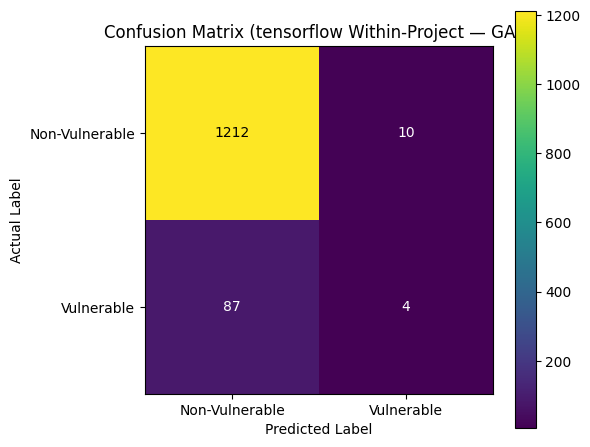

In [2]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on tensorflow (train split) -> Test on tensorflow (test split)
GAN Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED        = 42
PROJECT     = "tensorflow"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/gan"

LATENT_DIM  = 64
GAN_EPOCHS  = 300
GAN_LR      = 1e-4
BATCH_SIZE  = 64

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Main Classifier
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# GAN Models
# =========================================================
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# =========================================================
# GAN Oversampling
# =========================================================
def train_gan_and_generate(minority_samples, n_generate):
    """
    Train a simple GAN on minority-class embeddings only
    and generate synthetic vulnerable samples.
    """
    input_dim = minority_samples.shape[1]

    generator     = Generator(LATENT_DIM, input_dim).to(DEVICE)
    discriminator = Discriminator(input_dim).to(DEVICE)

    g_optimizer = torch.optim.Adam(generator.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
    criterion   = nn.BCELoss()

    minority_tensor = torch.tensor(minority_samples, dtype=torch.float32)
    loader = DataLoader(TensorDataset(minority_tensor), batch_size=min(BATCH_SIZE, len(minority_samples)), shuffle=True)

    for epoch in tqdm(range(GAN_EPOCHS), desc="GAN Training", leave=False):
        for (real_batch,) in loader:
            real_batch = real_batch.to(DEVICE)
            batch_size = real_batch.size(0)

            real_labels = torch.ones(batch_size, 1).to(DEVICE)
            fake_labels = torch.zeros(batch_size, 1).to(DEVICE)

            # Train discriminator
            d_optimizer.zero_grad()
            real_preds = discriminator(real_batch)
            d_loss_real = criterion(real_preds, real_labels)

            z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
            fake_batch = generator(z)
            fake_preds = discriminator(fake_batch.detach())
            d_loss_fake = criterion(fake_preds, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            d_optimizer.step()

            # Train generator
            g_optimizer.zero_grad()
            z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
            fake_batch = generator(z)
            fake_preds = discriminator(fake_batch)
            g_loss = criterion(fake_preds, real_labels)
            g_loss.backward()
            g_optimizer.step()

        if (epoch + 1) % 50 == 0:
            print(f"      GAN Epoch {epoch+1}/{GAN_EPOCHS} - D_loss: {d_loss.item():.4f} - G_loss: {g_loss.item():.4f}")

    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_generate, LATENT_DIM).to(DEVICE)
        synthetic = generator(z).cpu().numpy().astype(np.float32)

    return synthetic


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr, dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr, dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — GAN)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | GAN ===")
    print(f"    Device: {DEVICE}")

    print("\n[1/6] Loading embeddings...")
    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")

    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    print("\n[3/6] Applying GAN oversampling...")
    minority_samples = train_emb[train_lbl == 1]
    majority_samples = train_emb[train_lbl == 0]

    n_neg_before = len(majority_samples)
    n_pos_before = len(minority_samples)
    print(f"      Before GAN — benign: {n_neg_before} | vuln: {n_pos_before} | ratio: {n_neg_before / n_pos_before:.2f}")

    n_to_generate = n_neg_before - n_pos_before
    if n_to_generate > 0 and n_pos_before > 1:
        synthetic_minority = train_gan_and_generate(minority_samples, n_to_generate)
        train_emb_res = np.vstack([train_emb, synthetic_minority]).astype(np.float32)
        train_lbl_res = np.concatenate([train_lbl, np.ones(n_to_generate, dtype=np.int32)])
    else:
        print("      GAN oversampling skipped: insufficient minority samples or already balanced.")
        train_emb_res = train_emb.copy()
        train_lbl_res = train_lbl.copy()

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  GAN — benign: {n_neg_after} | vuln: {n_pos_after} | ratio: {n_neg_after / max(n_pos_after,1):.2f}")

    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w) for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-GAN): {class_weights}")

    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights = np.where(train_lbl_res == 1, y_train_pred, 1 - y_train_pred)
        model_xgb      = train_base_model_xgb(
                             train_emb_res, train_lbl_res,
                             class_weights,
                             sample_weights
                         )
        model_xgb_pred = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl, y_pred_final)
    recall    = recall_score(test_lbl, y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl, ensemble_avg)
    f1        = f1_score(test_lbl, y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"          : "gan_within_project",
        "setting"             : "within_project",
        "project"             : PROJECT,
        "latent_dim"          : LATENT_DIM,
        "gan_epochs"          : GAN_EPOCHS,
        "gan_lr"              : GAN_LR,
        "n_train_before_gan"  : int(len(train_lbl)),
        "n_train_after_gan"   : int(len(train_lbl_res)),
        "n_vuln_before_gan"   : n_pos_before,
        "n_benign_before_gan" : n_neg_before,
        "n_vuln_after_gan"    : n_pos_after,
        "n_benign_after_gan"  : n_neg_after,
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_test"         : int(test_lbl.sum()),
        "class_weights"       : class_weights,
        "accuracy"            : round(float(accuracy), 4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall), 4),
        "f1"                  : round(float(f1), 4),
        "auc"                 : round(float(auc), 4),
        "g_mean"              : round(float(g_mean), 4),
        "pf"                  : round(float(pf), 4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"gan_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_gan_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: vim | GAN ===
    Device: mps

[1/6] Loading embeddings...
      Train (vim): (951, 768)  vuln=38  benign=913
      Test  (vim): (1669, 768)  vuln=61  benign=1608

[2/6] Normalising embeddings...

[3/6] Applying GAN oversampling...
      Before GAN — benign: 913 | vuln: 38 | ratio: 24.03


GAN Training:   0%|          | 0/300 [00:00<?, ?it/s]

      GAN Epoch 50/300 - D_loss: 1.0092 - G_loss: 0.6179
      GAN Epoch 100/300 - D_loss: 1.2683 - G_loss: 0.6075
      GAN Epoch 150/300 - D_loss: 1.2048 - G_loss: 0.7927
      GAN Epoch 200/300 - D_loss: 1.0311 - G_loss: 0.9234
      GAN Epoch 250/300 - D_loss: 0.8306 - G_loss: 0.9720
      GAN Epoch 300/300 - D_loss: 0.7370 - G_loss: 1.0786
      After  GAN — benign: 913 | vuln: 913 | ratio: 1.00

[4/6] Computing class weights...
      Class weights (post-GAN): {0: 1.0, 1: 1.0}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


...

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6998
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6995
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6991
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6987
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6983
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6977
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6971
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.6963
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.6954
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.6943
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.6931
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.6917
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.6902
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.6886
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.6867
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.6844
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6951
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6945
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6934
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6922
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6911
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6898
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6883
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.6866
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.6847
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.6823
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.6798
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.6769
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.6737
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.6699
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.6656
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.6609
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6926
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6920
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6913
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6906
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6898
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6889
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.6878
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.6866
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.6854
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.6838
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.6822
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.6801
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.6776
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.6746
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.6711
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.6671
 

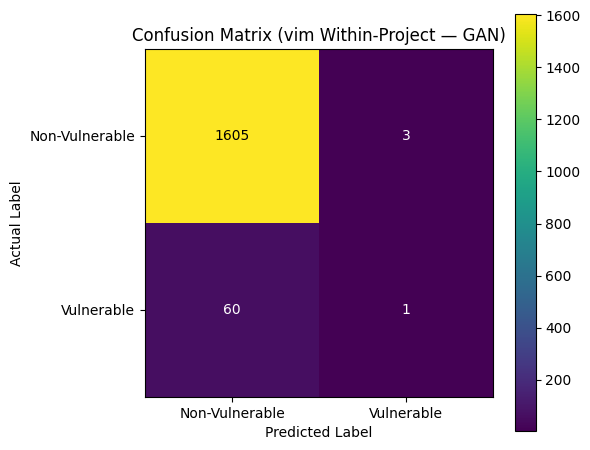

In [3]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on vim (train split) -> Test on vim (test split)
GAN Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED        = 42
PROJECT     = "vim"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/gan"

LATENT_DIM  = 64
GAN_EPOCHS  = 300
GAN_LR      = 1e-4
BATCH_SIZE  = 64

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Main Classifier
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# GAN Models
# =========================================================
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# =========================================================
# GAN Oversampling
# =========================================================
def train_gan_and_generate(minority_samples, n_generate):
    """
    Train a simple GAN on minority-class embeddings only
    and generate synthetic vulnerable samples.
    """
    input_dim = minority_samples.shape[1]

    generator     = Generator(LATENT_DIM, input_dim).to(DEVICE)
    discriminator = Discriminator(input_dim).to(DEVICE)

    g_optimizer = torch.optim.Adam(generator.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
    criterion   = nn.BCELoss()

    minority_tensor = torch.tensor(minority_samples, dtype=torch.float32)
    loader = DataLoader(TensorDataset(minority_tensor), batch_size=min(BATCH_SIZE, len(minority_samples)), shuffle=True)

    for epoch in tqdm(range(GAN_EPOCHS), desc="GAN Training", leave=False):
        for (real_batch,) in loader:
            real_batch = real_batch.to(DEVICE)
            batch_size = real_batch.size(0)

            real_labels = torch.ones(batch_size, 1).to(DEVICE)
            fake_labels = torch.zeros(batch_size, 1).to(DEVICE)

            # Train discriminator
            d_optimizer.zero_grad()
            real_preds = discriminator(real_batch)
            d_loss_real = criterion(real_preds, real_labels)

            z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
            fake_batch = generator(z)
            fake_preds = discriminator(fake_batch.detach())
            d_loss_fake = criterion(fake_preds, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            d_optimizer.step()

            # Train generator
            g_optimizer.zero_grad()
            z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
            fake_batch = generator(z)
            fake_preds = discriminator(fake_batch)
            g_loss = criterion(fake_preds, real_labels)
            g_loss.backward()
            g_optimizer.step()

        if (epoch + 1) % 50 == 0:
            print(f"      GAN Epoch {epoch+1}/{GAN_EPOCHS} - D_loss: {d_loss.item():.4f} - G_loss: {g_loss.item():.4f}")

    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_generate, LATENT_DIM).to(DEVICE)
        synthetic = generator(z).cpu().numpy().astype(np.float32)

    return synthetic


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr, dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr, dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — GAN)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | GAN ===")
    print(f"    Device: {DEVICE}")

    print("\n[1/6] Loading embeddings...")
    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")

    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    print("\n[3/6] Applying GAN oversampling...")
    minority_samples = train_emb[train_lbl == 1]
    majority_samples = train_emb[train_lbl == 0]

    n_neg_before = len(majority_samples)
    n_pos_before = len(minority_samples)
    print(f"      Before GAN — benign: {n_neg_before} | vuln: {n_pos_before} | ratio: {n_neg_before / n_pos_before:.2f}")

    n_to_generate = n_neg_before - n_pos_before
    if n_to_generate > 0 and n_pos_before > 1:
        synthetic_minority = train_gan_and_generate(minority_samples, n_to_generate)
        train_emb_res = np.vstack([train_emb, synthetic_minority]).astype(np.float32)
        train_lbl_res = np.concatenate([train_lbl, np.ones(n_to_generate, dtype=np.int32)])
    else:
        print("      GAN oversampling skipped: insufficient minority samples or already balanced.")
        train_emb_res = train_emb.copy()
        train_lbl_res = train_lbl.copy()

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  GAN — benign: {n_neg_after} | vuln: {n_pos_after} | ratio: {n_neg_after / max(n_pos_after,1):.2f}")

    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w) for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-GAN): {class_weights}")

    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights = np.where(train_lbl_res == 1, y_train_pred, 1 - y_train_pred)
        model_xgb      = train_base_model_xgb(
                             train_emb_res, train_lbl_res,
                             class_weights,
                             sample_weights
                         )
        model_xgb_pred = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl, y_pred_final)
    recall    = recall_score(test_lbl, y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl, ensemble_avg)
    f1        = f1_score(test_lbl, y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"          : "gan_within_project",
        "setting"             : "within_project",
        "project"             : PROJECT,
        "latent_dim"          : LATENT_DIM,
        "gan_epochs"          : GAN_EPOCHS,
        "gan_lr"              : GAN_LR,
        "n_train_before_gan"  : int(len(train_lbl)),
        "n_train_after_gan"   : int(len(train_lbl_res)),
        "n_vuln_before_gan"   : n_pos_before,
        "n_benign_before_gan" : n_neg_before,
        "n_vuln_after_gan"    : n_pos_after,
        "n_benign_after_gan"  : n_neg_after,
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_test"         : int(test_lbl.sum()),
        "class_weights"       : class_weights,
        "accuracy"            : round(float(accuracy), 4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall), 4),
        "f1"                  : round(float(f1), 4),
        "auc"                 : round(float(auc), 4),
        "g_mean"              : round(float(g_mean), 4),
        "pf"                  : round(float(pf), 4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"gan_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_gan_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: gpac | GAN ===
    Device: mps

[1/6] Loading embeddings...
      Train (gpac): (2775, 768)  vuln=32  benign=2743
      Test  (gpac): (1884, 768)  vuln=18  benign=1866

[2/6] Normalising embeddings...

[3/6] Applying GAN oversampling...
      Before GAN — benign: 2743 | vuln: 32 | ratio: 85.72


GAN Training:   0%|          | 0/300 [00:00<?, ?it/s]

      GAN Epoch 50/300 - D_loss: 0.9552 - G_loss: 0.6256
      GAN Epoch 100/300 - D_loss: 1.2469 - G_loss: 0.5684
      GAN Epoch 150/300 - D_loss: 1.2403 - G_loss: 0.6989
      GAN Epoch 200/300 - D_loss: 1.1864 - G_loss: 0.7815
      GAN Epoch 250/300 - D_loss: 0.9372 - G_loss: 0.9476
      GAN Epoch 300/300 - D_loss: 0.9135 - G_loss: 1.0227
      After  GAN — benign: 2743 | vuln: 2743 | ratio: 1.00

[4/6] Computing class weights...
      Class weights (post-GAN): {0: 1.0, 1: 1.0}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


...

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6890
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6857
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6819
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6772
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6702
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6591
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6421
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.6167
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.5789
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.5274
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.4648
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.3958
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.3257
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.2608
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.2080
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.1640
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6897
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6809
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6683
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6506
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6259
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.5940
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.5552
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.5131
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.4721
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.4349
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.4007
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.3682
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.3391
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.3086
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.2777
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.2401
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6895
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6838
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6759
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6639
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6468
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6235
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.5931
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.5590
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.5247
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.4916
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.4606
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.4303
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.4007
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.3715
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.3395
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.3058
 

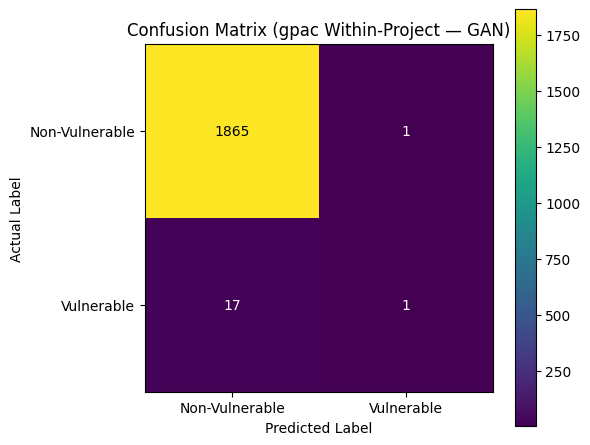

In [4]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on gpac (train split) -> Test on gpac (test split)
GAN Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED        = 42
PROJECT     = "gpac"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/gan"

LATENT_DIM  = 64
GAN_EPOCHS  = 300
GAN_LR      = 1e-4
BATCH_SIZE  = 64

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Main Classifier
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# GAN Models
# =========================================================
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# =========================================================
# GAN Oversampling
# =========================================================
def train_gan_and_generate(minority_samples, n_generate):
    """
    Train a simple GAN on minority-class embeddings only
    and generate synthetic vulnerable samples.
    """
    input_dim = minority_samples.shape[1]

    generator     = Generator(LATENT_DIM, input_dim).to(DEVICE)
    discriminator = Discriminator(input_dim).to(DEVICE)

    g_optimizer = torch.optim.Adam(generator.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
    criterion   = nn.BCELoss()

    minority_tensor = torch.tensor(minority_samples, dtype=torch.float32)
    loader = DataLoader(TensorDataset(minority_tensor), batch_size=min(BATCH_SIZE, len(minority_samples)), shuffle=True)

    for epoch in tqdm(range(GAN_EPOCHS), desc="GAN Training", leave=False):
        for (real_batch,) in loader:
            real_batch = real_batch.to(DEVICE)
            batch_size = real_batch.size(0)

            real_labels = torch.ones(batch_size, 1).to(DEVICE)
            fake_labels = torch.zeros(batch_size, 1).to(DEVICE)

            # Train discriminator
            d_optimizer.zero_grad()
            real_preds = discriminator(real_batch)
            d_loss_real = criterion(real_preds, real_labels)

            z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
            fake_batch = generator(z)
            fake_preds = discriminator(fake_batch.detach())
            d_loss_fake = criterion(fake_preds, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            d_optimizer.step()

            # Train generator
            g_optimizer.zero_grad()
            z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
            fake_batch = generator(z)
            fake_preds = discriminator(fake_batch)
            g_loss = criterion(fake_preds, real_labels)
            g_loss.backward()
            g_optimizer.step()

        if (epoch + 1) % 50 == 0:
            print(f"      GAN Epoch {epoch+1}/{GAN_EPOCHS} - D_loss: {d_loss.item():.4f} - G_loss: {g_loss.item():.4f}")

    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_generate, LATENT_DIM).to(DEVICE)
        synthetic = generator(z).cpu().numpy().astype(np.float32)

    return synthetic


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr, dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr, dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — GAN)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | GAN ===")
    print(f"    Device: {DEVICE}")

    print("\n[1/6] Loading embeddings...")
    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")

    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    print("\n[3/6] Applying GAN oversampling...")
    minority_samples = train_emb[train_lbl == 1]
    majority_samples = train_emb[train_lbl == 0]

    n_neg_before = len(majority_samples)
    n_pos_before = len(minority_samples)
    print(f"      Before GAN — benign: {n_neg_before} | vuln: {n_pos_before} | ratio: {n_neg_before / n_pos_before:.2f}")

    n_to_generate = n_neg_before - n_pos_before
    if n_to_generate > 0 and n_pos_before > 1:
        synthetic_minority = train_gan_and_generate(minority_samples, n_to_generate)
        train_emb_res = np.vstack([train_emb, synthetic_minority]).astype(np.float32)
        train_lbl_res = np.concatenate([train_lbl, np.ones(n_to_generate, dtype=np.int32)])
    else:
        print("      GAN oversampling skipped: insufficient minority samples or already balanced.")
        train_emb_res = train_emb.copy()
        train_lbl_res = train_lbl.copy()

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  GAN — benign: {n_neg_after} | vuln: {n_pos_after} | ratio: {n_neg_after / max(n_pos_after,1):.2f}")

    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w) for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-GAN): {class_weights}")

    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights = np.where(train_lbl_res == 1, y_train_pred, 1 - y_train_pred)
        model_xgb      = train_base_model_xgb(
                             train_emb_res, train_lbl_res,
                             class_weights,
                             sample_weights
                         )
        model_xgb_pred = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl, y_pred_final)
    recall    = recall_score(test_lbl, y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl, ensemble_avg)
    f1        = f1_score(test_lbl, y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"          : "gan_within_project",
        "setting"             : "within_project",
        "project"             : PROJECT,
        "latent_dim"          : LATENT_DIM,
        "gan_epochs"          : GAN_EPOCHS,
        "gan_lr"              : GAN_LR,
        "n_train_before_gan"  : int(len(train_lbl)),
        "n_train_after_gan"   : int(len(train_lbl_res)),
        "n_vuln_before_gan"   : n_pos_before,
        "n_benign_before_gan" : n_neg_before,
        "n_vuln_after_gan"    : n_pos_after,
        "n_benign_after_gan"  : n_neg_after,
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_test"         : int(test_lbl.sum()),
        "class_weights"       : class_weights,
        "accuracy"            : round(float(accuracy), 4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall), 4),
        "f1"                  : round(float(f1), 4),
        "auc"                 : round(float(auc), 4),
        "g_mean"              : round(float(g_mean), 4),
        "pf"                  : round(float(pf), 4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"gan_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_gan_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: FreeRDP | GAN ===
    Device: mps

[1/6] Loading embeddings...
      Train (FreeRDP): (872, 768)  vuln=23  benign=849
      Test  (FreeRDP): (26, 768)  vuln=1  benign=25

[2/6] Normalising embeddings...

[3/6] Applying GAN oversampling...
      Before GAN — benign: 849 | vuln: 23 | ratio: 36.91


GAN Training:   0%|          | 0/300 [00:00<?, ?it/s]

      GAN Epoch 50/300 - D_loss: 0.9660 - G_loss: 0.6430
      GAN Epoch 100/300 - D_loss: 1.1939 - G_loss: 0.6026
      GAN Epoch 150/300 - D_loss: 1.0999 - G_loss: 0.8018
      GAN Epoch 200/300 - D_loss: 0.9828 - G_loss: 0.8960
      GAN Epoch 250/300 - D_loss: 0.8405 - G_loss: 0.9571
      GAN Epoch 300/300 - D_loss: 0.7030 - G_loss: 1.0951
      After  GAN — benign: 849 | vuln: 849 | ratio: 1.00

[4/6] Computing class weights...
      Class weights (post-GAN): {0: 1.0, 1: 1.0}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


...

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6913
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6904
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6894
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6884
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6873
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6861
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6849
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.6835
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.6819
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.6802
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.6783
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.6763
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.6739
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.6711
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.6679
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.6641
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6945
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6936
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6927
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6918
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6907
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6896
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6884
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.6870
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.6855
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.6838
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.6820
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.6800
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.6778
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.6753
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.6726
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.6696
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6906
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6885
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6866
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6847
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6828
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6807
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.6782
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.6754
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.6723
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.6689
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.6652
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.6614
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.6575
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.6530
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.6484
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.6434
 

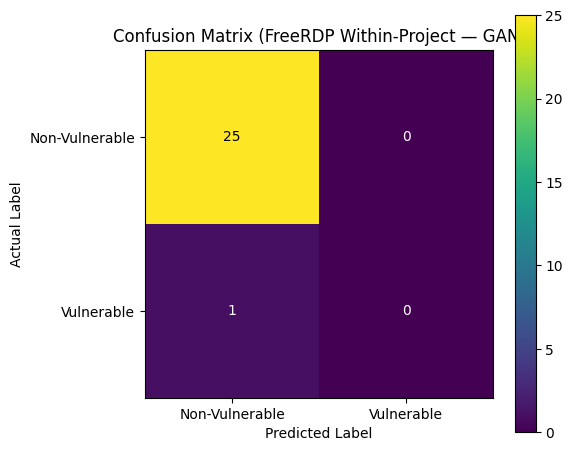

In [5]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on FreeRDP (train split) -> Test on FreeRDP (test split)
GAN Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED        = 42
PROJECT     = "FreeRDP"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/gan"

LATENT_DIM  = 64
GAN_EPOCHS  = 300
GAN_LR      = 1e-4
BATCH_SIZE  = 64

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Main Classifier
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# GAN Models
# =========================================================
class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# =========================================================
# GAN Oversampling
# =========================================================
def train_gan_and_generate(minority_samples, n_generate):
    """
    Train a simple GAN on minority-class embeddings only
    and generate synthetic vulnerable samples.
    """
    input_dim = minority_samples.shape[1]

    generator     = Generator(LATENT_DIM, input_dim).to(DEVICE)
    discriminator = Discriminator(input_dim).to(DEVICE)

    g_optimizer = torch.optim.Adam(generator.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=GAN_LR, betas=(0.5, 0.999))
    criterion   = nn.BCELoss()

    minority_tensor = torch.tensor(minority_samples, dtype=torch.float32)
    loader = DataLoader(TensorDataset(minority_tensor), batch_size=min(BATCH_SIZE, len(minority_samples)), shuffle=True)

    for epoch in tqdm(range(GAN_EPOCHS), desc="GAN Training", leave=False):
        for (real_batch,) in loader:
            real_batch = real_batch.to(DEVICE)
            batch_size = real_batch.size(0)

            real_labels = torch.ones(batch_size, 1).to(DEVICE)
            fake_labels = torch.zeros(batch_size, 1).to(DEVICE)

            # Train discriminator
            d_optimizer.zero_grad()
            real_preds = discriminator(real_batch)
            d_loss_real = criterion(real_preds, real_labels)

            z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
            fake_batch = generator(z)
            fake_preds = discriminator(fake_batch.detach())
            d_loss_fake = criterion(fake_preds, fake_labels)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            d_optimizer.step()

            # Train generator
            g_optimizer.zero_grad()
            z = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
            fake_batch = generator(z)
            fake_preds = discriminator(fake_batch)
            g_loss = criterion(fake_preds, real_labels)
            g_loss.backward()
            g_optimizer.step()

        if (epoch + 1) % 50 == 0:
            print(f"      GAN Epoch {epoch+1}/{GAN_EPOCHS} - D_loss: {d_loss.item():.4f} - G_loss: {g_loss.item():.4f}")

    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_generate, LATENT_DIM).to(DEVICE)
        synthetic = generator(z).cpu().numpy().astype(np.float32)

    return synthetic


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr, dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr, dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — GAN)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | GAN ===")
    print(f"    Device: {DEVICE}")

    print("\n[1/6] Loading embeddings...")
    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")

    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    print("\n[3/6] Applying GAN oversampling...")
    minority_samples = train_emb[train_lbl == 1]
    majority_samples = train_emb[train_lbl == 0]

    n_neg_before = len(majority_samples)
    n_pos_before = len(minority_samples)
    print(f"      Before GAN — benign: {n_neg_before} | vuln: {n_pos_before} | ratio: {n_neg_before / n_pos_before:.2f}")

    n_to_generate = n_neg_before - n_pos_before
    if n_to_generate > 0 and n_pos_before > 1:
        synthetic_minority = train_gan_and_generate(minority_samples, n_to_generate)
        train_emb_res = np.vstack([train_emb, synthetic_minority]).astype(np.float32)
        train_lbl_res = np.concatenate([train_lbl, np.ones(n_to_generate, dtype=np.int32)])
    else:
        print("      GAN oversampling skipped: insufficient minority samples or already balanced.")
        train_emb_res = train_emb.copy()
        train_lbl_res = train_lbl.copy()

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  GAN — benign: {n_neg_after} | vuln: {n_pos_after} | ratio: {n_neg_after / max(n_pos_after,1):.2f}")

    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w) for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-GAN): {class_weights}")

    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights = np.where(train_lbl_res == 1, y_train_pred, 1 - y_train_pred)
        model_xgb      = train_base_model_xgb(
                             train_emb_res, train_lbl_res,
                             class_weights,
                             sample_weights
                         )
        model_xgb_pred = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl, y_pred_final)
    recall    = recall_score(test_lbl, y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl, ensemble_avg)
    f1        = f1_score(test_lbl, y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"          : "gan_within_project",
        "setting"             : "within_project",
        "project"             : PROJECT,
        "latent_dim"          : LATENT_DIM,
        "gan_epochs"          : GAN_EPOCHS,
        "gan_lr"              : GAN_LR,
        "n_train_before_gan"  : int(len(train_lbl)),
        "n_train_after_gan"   : int(len(train_lbl_res)),
        "n_vuln_before_gan"   : n_pos_before,
        "n_benign_before_gan" : n_neg_before,
        "n_vuln_after_gan"    : n_pos_after,
        "n_benign_after_gan"  : n_neg_after,
        "n_test_samples"      : int(len(test_lbl)),
        "n_vuln_test"         : int(test_lbl.sum()),
        "class_weights"       : class_weights,
        "accuracy"            : round(float(accuracy), 4),
        "precision"           : round(float(precision), 4),
        "recall"              : round(float(recall), 4),
        "f1"                  : round(float(f1), 4),
        "auc"                 : round(float(auc), 4),
        "g_mean"              : round(float(g_mean), 4),
        "pf"                  : round(float(pf), 4),
        "confusion_matrix"    : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"gan_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_gan_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()